In [1]:
import os

os.environ["OMP_NUM_THREADS"] = "20"
os.environ["MKL_NUM_THREADS"] = "20"

import torch
torch.set_num_threads(20)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [2]:
import random
import cv2
import numpy as np
from pathlib import Path
from tqdm import tqdm

import torch.nn as nn

from torch.utils.data import Dataset, DataLoader, random_split
from torchvision.models.video import r3d_18

from sklearn.metrics import classification_report, confusion_matrix

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
class VideoDataset(Dataset):

    def __init__(self, root, frames=16, spatial_size=112):

        self.root = Path(root)
        self.frames = frames
        self.spatial_size = spatial_size

        self.samples = []

        normal_folder = self.root / "normal"
        crime_folder = self.root / "crime"

        exts = (".mp4",".avi",".mov",".mkv")

        for p in normal_folder.rglob("*"):
            if p.suffix.lower() in exts:
                self.samples.append((str(p),0))

        for p in crime_folder.rglob("*"):
            if p.suffix.lower() in exts:
                self.samples.append((str(p),1))


    def __len__(self):
        return len(self.samples)


    def __getitem__(self, idx):

        path, label = self.samples[idx]

        cap = cv2.VideoCapture(path)
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

        if frame_count <= 0:
            frame_count = self.frames

        indices = np.linspace(0, frame_count-1, self.frames).astype(int)

        frames = []

        for i in indices:

            cap.set(cv2.CAP_PROP_POS_FRAMES, int(i))
            ret, frame = cap.read()

            if not ret:
                frame = np.zeros((self.spatial_size,self.spatial_size,3),dtype=np.uint8)

            frame = cv2.resize(frame,(self.spatial_size,self.spatial_size))
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

            frame = torch.tensor(frame).permute(2,0,1).float()/255.0
            frames.append(frame)

        cap.release()

        clip = torch.stack(frames)
        clip = clip.permute(1,0,2,3)

        return clip, torch.tensor(label).float()

In [5]:
DATA_ROOT = r"D:\Dtaset fot cctv\UCF"

frames = 32
spatial = 128
batch_size = 4

dataset = VideoDataset(DATA_ROOT, frames=frames, spatial_size=spatial)

print("Total videos:", len(dataset))

Total videos: 1900


In [6]:
val_size = int(0.2 * len(dataset))
train_size = len(dataset) - val_size

train_ds, val_ds = random_split(dataset,[train_size,val_size])

print("Train:", len(train_ds))
print("Validation:", len(val_ds))

Train: 1520
Validation: 380


In [7]:
val_loader = DataLoader(
    val_ds,
    batch_size=batch_size,
    shuffle=False,
    num_workers=0
)

In [8]:
MODEL_PATH = r"C:\Users\amarh\Desktop\My Professionals\Projects\CCTV Crime\Models\s3_r3d_epoch_4.pth"

model = r3d_18(pretrained=False)

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features,1)
)

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))

model = model.to(device)
model.eval()

print("Model loaded successfully")

C:\Users\amarh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\amarh\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Model loaded successfully


In [9]:
all_preds = []
all_labels = []

correct = 0
total = 0

with torch.no_grad():

    for clips, labels in tqdm(val_loader):

        clips = clips.to(device)
        labels = labels.to(device)

        logits = model(clips).squeeze(1)

        probs = torch.sigmoid(logits)

        preds = (probs > 0.5).float()

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

100%|██████████| 95/95 [06:42<00:00,  4.23s/it]


In [10]:
accuracy = correct / total

print("Validation Accuracy:", accuracy)

Validation Accuracy: 0.9026315789473685


In [11]:
print("\nClassification Report\n")

print(
    classification_report(
        all_labels,
        all_preds,
        target_names=["Normal","Crime"]
    )
)

print("\nConfusion Matrix\n")

print(confusion_matrix(all_labels, all_preds))


Classification Report

              precision    recall  f1-score   support

      Normal       0.88      0.93      0.90       189
       Crime       0.93      0.87      0.90       191

    accuracy                           0.90       380
   macro avg       0.90      0.90      0.90       380
weighted avg       0.90      0.90      0.90       380


Confusion Matrix

[[176  13]
 [ 24 167]]


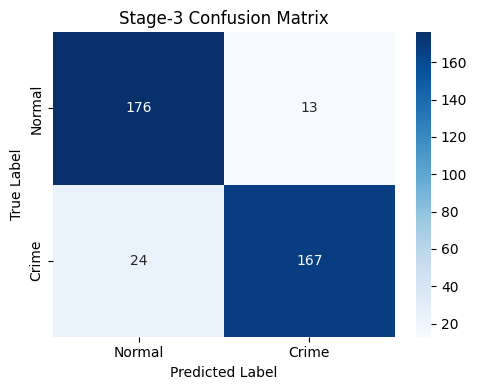

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

cm = np.array([[176,13],
               [24,167]])

labels = ["Normal", "Crime"]

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=labels,
            yticklabels=labels)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Stage-3 Confusion Matrix")

plt.tight_layout()
plt.savefig("stage3_confusion_matrix.png", dpi=300)
plt.show()